# Panoptica Tutorial: Liver Metastasis Segmentation & Instance Matching

Welcome to this comprehensive tutorial on using **Panoptica** for advanced medical image segmentation evaluation! 

In this notebook, you will learn how to use **Panoptica**  for:
1. Setup in a Colab/Jupyter environment.
2. Load NIfTI medical images (CT scans, reference masks, and predictions).
3. Perform basic Semantic Segmentation Evaluation.
4. Utilize different Instance Matching algorithms.
5. Analyze the effect of varying decision thresholds on evaluation metrics.

## 1. Setup & Installation
If you are running this in Google Colab or a fresh environment, you will need to install `panoptica` and other dependencies. Uncomment and run the cell below to install them.

In [ ]:
# !pip install panoptica nibabel matplotlib numpy

Now, let's import the necessary Python packages.

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
from panoptica.metrics import Metric
from auxiliary.nifti.io import read_nifti
from panoptica import Panoptica_Evaluator, InputType
from panoptica.instance_approximator import ConnectedComponentsInstanceApproximator
from panoptica.instance_matcher import (
    NaiveThresholdMatching,
    MaxBipartiteMatching,
    MaximizeMergeMatching
)
from IPython.display import Image, display

## 2. Liver Lesion Segmentation

Liver lesions exhibit significant morphological heterogeneity, manifesting in diverse sizes, shapes, and textures across the eight anatomical segments of the liver. While certain lesions present a distinct intensity profile relative to the surrounding healthy parenchyma in CT images, others demonstrate poor contrast, rendering them nearly indistinguishable from normal liver structures.

The examined sample in this tutorial is adopted from the **RadGPT** dataset:
*RadGPT: Constructing 3D Image-Text Tumor Datasets*; Pedro R. A. S. Bassi et. al. ; https://doi.org/10.48550/arXiv.2501.04678

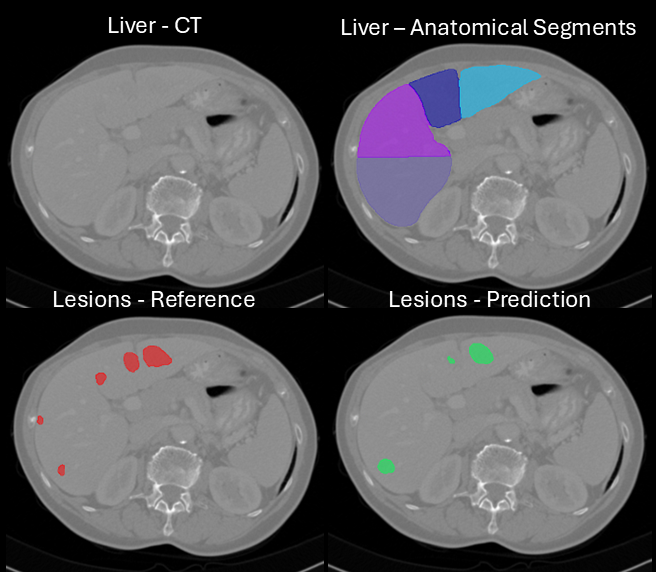

In [38]:
display(Image(filename="./liver_data/liver_example.png"))

## 3. Data Preparation
We will load our sample data: an original CT scan, a ground truth reference mask, and a predicted mask. 

*If you are in Google Colab, make sure you upload the `liver_data` folder or mount your Google Drive containing the data.*

In [39]:
data_dir = "./liver_data"
ct_path = os.path.join(data_dir, "ct.nii.gz")
ref_path = os.path.join(data_dir, "reference.nii.gz")
pred_path = os.path.join(data_dir, "pred.nii.gz")


# Load NIfTI files and extract the numpy arrays
ct_img = read_nifti(ct_path)
ref_mask = read_nifti(ref_path)
pred_mask = read_nifti(pred_path)
print("Data loaded successfully from", data_dir)

Data loaded successfully from ./liver_data


## 4. Semantic Segementation

In [40]:
evaluator = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=NaiveThresholdMatching(),
)

# print all results
result = evaluator.evaluate(pred_mask, ref_mask, verbose=False)["ungrouped"]
print(result)


+++ MATCHING +++
Number of instances in reference (num_ref_instances): 17
Number of instances in prediction (num_pred_instances): 6
True Positives (tp): 3
False Positives (fp): 3
False Negatives (fn): 14
Recognition Quality / F1-Score (rq): 0.2608695652173913

+++ GLOBAL +++
Global Binary Dice (global_bin_dsc): 0.7984426392732317

+++ INSTANCE +++
Segmentation Quality IoU (sq): 0.6657926972986284 +- 0.07858703198734981
Panoptic Quality IoU (pq): 0.1736850514692074
Segmentation Quality Dsc (sq_dsc): 0.7967198274342439 +- 0.05621213750206766
Panoptic Quality Dsc (pq_dsc): 0.20783995498284621
Segmentation Quality ASSD (sq_assd): 1.4308809846573343 +- 0.20515254165298558
Segmentation Quality Relative Volume Difference (sq_rvd): 0.1268804355079294 +- 0.19261738567904374



## 5. Exploring Instance Matchers
In Panoptica, to evaluate instance-level metrics, we first approximate instances (using Connected Components for binary masks). Then, we map predicted instances to reference instances using a matching strategy.

Here, we will define a standard threshold of `0.5` (IoU >= 0.5 to be a match) and test different algorithms.

In [41]:
decision_threshold = 0.5

# Define the matchers we want to compare
matchers = {
    "NaiveThreshold": NaiveThresholdMatching(matching_metric=Metric.IOU, matching_threshold=decision_threshold),
    "MaxBipartite": MaxBipartiteMatching(matching_metric=Metric.IOU, matching_threshold=decision_threshold),
    "MaximizeMerge": MaximizeMergeMatching(matching_metric=Metric.IOU, matching_threshold=decision_threshold),
}

matching_results = {}

print("Evaluating matchers...")
for name, matcher in matchers.items():
    try:
        evaluator = Panoptica_Evaluator(
            expected_input=InputType.SEMANTIC,
            instance_approximator=ConnectedComponentsInstanceApproximator(),
            instance_matcher=matcher
        )
        res = evaluator.evaluate(pred_mask, ref_mask, verbose=False)["ungrouped"]
        matching_results[name] = res
        print(f"[✓] {name} completed.")
    except Exception as e:
        print(f"[x] {name} failed: {e}")


Evaluating matchers...
[✓] NaiveThreshold completed.
[✓] MaxBipartite completed.
[✓] MaximizeMerge completed.


## 6. Comparing Matcher Results
Let's print out a clean table comparing the performance of the different instance matching algorithms. We will look at Panoptic Quality (PQ), Segmentation Quality (SQ), Recognition Quality (RQ), and the raw True Positive (TP), False Positive (FP), and False Negative (FN) instance counts.

In [42]:
print(f"{'Matcher':<15} | {'PQ':<6} | {'SQ':<6} | {'RQ':<6} | {'TP':<4} | {'FP':<4} | {'FN':<4}")
print("-" * 65)

for name, res in matching_results.items():
    # Safely extract metrics; default to 0 if not available
    pq = getattr(res, 'pq', 0.0)
    sq = getattr(res, 'sq', 0.0)
    rq = getattr(res, 'rq', 0.0)
    tp = getattr(res, 'tp', 0)
    fp = getattr(res, 'fp', 0)
    fn = getattr(res, 'fn', 0)
    
    print(f"{name:<15} | {pq:.4f} | {sq:.4f} | {rq:.4f} | {tp:<4} | {fp:<4} | {fn:<4}")


Matcher         | PQ     | SQ     | RQ     | TP   | FP   | FN  
-----------------------------------------------------------------
NaiveThreshold  | 0.1737 | 0.6658 | 0.2609 | 3    | 3    | 14  
MaxBipartite    | 0.1737 | 0.6658 | 0.2609 | 3    | 3    | 14  
MaximizeMerge   | 0.1737 | 0.6658 | 0.2609 | 3    | 3    | 14  


## 7. Threshold Analysis with MaxBipartiteMatching
The decision threshold dictates how much overlap is required to consider a prediction a "True Positive" match with a reference lesion. 

Let's sweep this threshold from **0.05 to 0.80** (step 0.05) using `MaxBipartiteMatching` and plot how Panoptic Quality and True Positive count degrade as the matching criterion becomes stricter.

Evaluating varying thresholds...
  [IoU >= 0.05] -> PQ: 0.1989 | TP: 6
  [IoU >= 0.10] -> PQ: 0.1943 | TP: 5
  [IoU >= 0.15] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.20] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.25] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.30] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.35] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.40] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.45] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.50] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.55] -> PQ: 0.1737 | TP: 3
  [IoU >= 0.60] -> PQ: 0.1235 | TP: 2
  [IoU >= 0.65] -> PQ: 0.1235 | TP: 2
  [IoU >= 0.70] -> PQ: 0.0668 | TP: 1
  [IoU >= 0.75] -> PQ: 0.0668 | TP: 1
  [IoU >= 0.80] -> PQ: 0.0000 | TP: 0
  [IoU >= 0.85] -> PQ: 0.0000 | TP: 0
  [IoU >= 0.90] -> PQ: 0.0000 | TP: 0
  [IoU >= 0.95] -> PQ: 0.0000 | TP: 0

Plotting results...


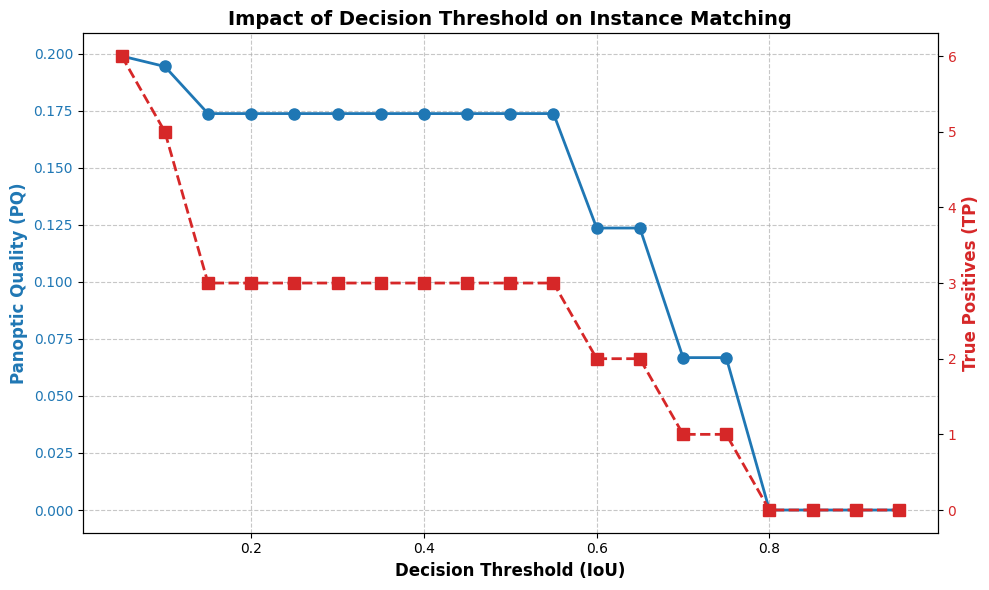

In [43]:
thresholds = np.arange(0.05, 1., 0.05)
pq_scores = []
tp_counts = []

print("Evaluating varying thresholds...")
for thresh in thresholds:
    matcher = MaxBipartiteMatching(matching_metric=Metric.IOU, matching_threshold=thresh)
    evaluator = Panoptica_Evaluator(
        expected_input=InputType.SEMANTIC,
        instance_approximator=ConnectedComponentsInstanceApproximator(),
        instance_matcher=matcher
    )
    res = evaluator.evaluate(pred_mask, ref_mask, verbose=False)["ungrouped"]
    
    pq = getattr(res, 'pq', 0.0)
    tp = getattr(res, 'tp', 0)
    
    pq_scores.append(pq)
    tp_counts.append(tp)
    
    print(f"  [IoU >= {thresh:.2f}] -> PQ: {pq:.4f} | TP: {tp}")

print("\nPlotting results...")

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Panoptic Quality on the left Y-axis
color = 'tab:blue'
ax1.set_xlabel('Decision Threshold (IoU)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Panoptic Quality (PQ)', color=color, fontsize=12, fontweight='bold')
ax1.plot(thresholds, pq_scores, marker='o', color=color, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot True Positives on the right Y-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('True Positives (TP)', color=color, fontsize=12, fontweight='bold')
ax2.plot(thresholds, tp_counts, marker='s', linestyle='--', color=color, linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)

# Set integer ticks for TP if possible
from matplotlib.ticker import MaxNLocator
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Impact of Decision Threshold on Instance Matching', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()
